# 01 — EDA · Home Credit Default Risk

**Taller B4-T1 — Diseño de Redes Confiables: Justicia e Incertidumbre**

Dataset: [Home Credit Default Risk](https://www.kaggle.com/datasets/megancrenshaw/home-credit-default-risk)

**Propósito.** Entender los datos antes de modelar y **cerrar las decisiones de preprocesado**. Este notebook es un *orquestador*: no define funciones (todo el código reutilizable vive en `src/`), lee `csvs/application_train.csv` y reutiliza el pipeline de `src/data.py` para mantener consistencia con el resto del proyecto.

**Decisiones que se justifican aquí:**
1. AUC (no accuracy) como objetivo del Tuner → desbalanceo ~11:1.
2. Calibración de `k` para `DebtRatioCustomLayer` como percentil 95 del ratio en *train*.
3. `log1p` + `RobustScaler` para `AMT_ANNUITY`.
4. Flags de imputación de `EXT_SOURCE_1/2/3` por su alta tasa de nulos.
5. Variable sensible `CODE_GENDER` **fuera** de las features de entrada por defecto.

## 0. Configuración

Se añade la raíz del repo a `sys.path` para poder importar `src.data`, garantizando que el EDA usa **exactamente el mismo pipeline** que entrenará el modelo.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Raíz del repo (un nivel por encima de notebooks/) para importar src/
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from src.data import load_and_split, make_extended_y

CSV = os.path.join(REPO_ROOT, "csvs", "application_train.csv")
SEED = 42

# Las 9 columnas del diseño (+ SK_ID_CURR como índice de trazabilidad)
USECOLS = [
    "SK_ID_CURR", "TARGET", "CODE_GENDER",
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
    "DAYS_BIRTH", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
]
EXT_SOURCE_COLS = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

C:\Users\diego\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. Carga de datos

Dos fuentes complementarias, ambas exigidas por el diseño:

- **DataFrame crudo** (`df`) para distribuciones marginales, correlaciones y exploración visual.
- **Split del pipeline** vía `load_and_split`, que aplica imputación/escalado **ajustados solo en train** y enruta las features en dos canales. Se usa sobre todo `X_custom_train` (`[AMT_CREDIT, AMT_INCOME_TOTAL]` crudo imputado) para calibrar `k` sin fuga de información.

In [2]:
df = pd.read_csv(CSV, usecols=USECOLS).set_index("SK_ID_CURR")
# Edad en años (positiva) solo para exploración; el pipeline la deriva igual en data.py
df["AGE"] = -df["DAYS_BIRTH"] / 365.25
df.shape

(307511, 10)

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 307511 entries, 100002 to 456255
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   TARGET            307511 non-null  int64  
 1   CODE_GENDER       307511 non-null  str    
 2   AMT_INCOME_TOTAL  307511 non-null  float64
 3   AMT_CREDIT        307511 non-null  float64
 4   AMT_ANNUITY       307499 non-null  float64
 5   DAYS_BIRTH        307511 non-null  int64  
 6   EXT_SOURCE_1      134133 non-null  float64
 7   EXT_SOURCE_2      306851 non-null  float64
 8   EXT_SOURCE_3      246546 non-null  float64
 9   AGE               307511 non-null  float64
dtypes: float64(7), int64(2), str(1)
memory usage: 26.1 MB


In [4]:
df.describe()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AGE
count,"307,511.0000","307,511.0000","307,511.0000","307,499.0000","307,511.0000","134,133.0000","306,851.0000","246,546.0000","307,511.0000"
mean,0.0807,"168,797.9193","599,025.9997","27,108.5739","-16,036.9951",0.5021,0.5144,0.5109,43.9069
std,0.2724,"237,123.1463","402,490.7770","14,493.7373","4,363.9886",0.2111,0.1911,0.1948,11.9479
min,0.0000,"25,650.0000","45,000.0000","1,615.5000","-25,229.0000",0.0146,0.0000,0.0005,20.5038
25%,0.0000,"112,500.0000","270,000.0000","16,524.0000","-19,682.0000",0.3340,0.3925,0.3706,33.9849
50%,0.0000,"147,150.0000","513,531.0000","24,903.0000","-15,750.0000",0.5060,0.5660,0.5353,43.1211
75%,0.0000,"202,500.0000","808,650.0000","34,596.0000","-12,413.0000",0.6751,0.6636,0.6691,53.8864
max,1.0000,"117,000,000.0000","4,050,000.0000","258,025.5000","-7,489.0000",0.9627,0.8550,0.8960,69.0732


In [5]:
# Split del pipeline (mismo SEED y misma estratificación que usará 02_model)
(
    X_custom_train, X_custom_val, X_custom_test,
    X_dense_train,  X_dense_val,  X_dense_test,
    y_train, y_val, y_test,
    s_train, s_val, s_test,
    scalers, feature_names,
) = load_and_split(CSV)

print("X_custom_train:", X_custom_train.shape, "->", feature_names["custom"])
print("X_dense_train :", X_dense_train.shape)
print("features dense:", feature_names["dense"])
print(f"tasa de impago (train): {y_train.mean():.4f}")

X_custom_train: (215257, 2) -> ['AMT_CREDIT', 'AMT_INCOME_TOTAL']
X_dense_train : (215257, 8)
features dense: ['AMT_ANNUITY', 'AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'is_imputed_EXT_SOURCE_1', 'is_imputed_EXT_SOURCE_2', 'is_imputed_EXT_SOURCE_3']
tasa de impago (train): 0.0807


## 2. Distribuciones marginales y correlaciones

Las variables monetarias (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`) tienen colas largas a la derecha → motivan transformaciones logarítmicas / escalado robusto. Los `EXT_SOURCE` ya viven en ~[0,1]. La correlación con `TARGET` es débil en general, salvo los `EXT_SOURCE` (negativa: a mayor score externo, menor riesgo de impago).

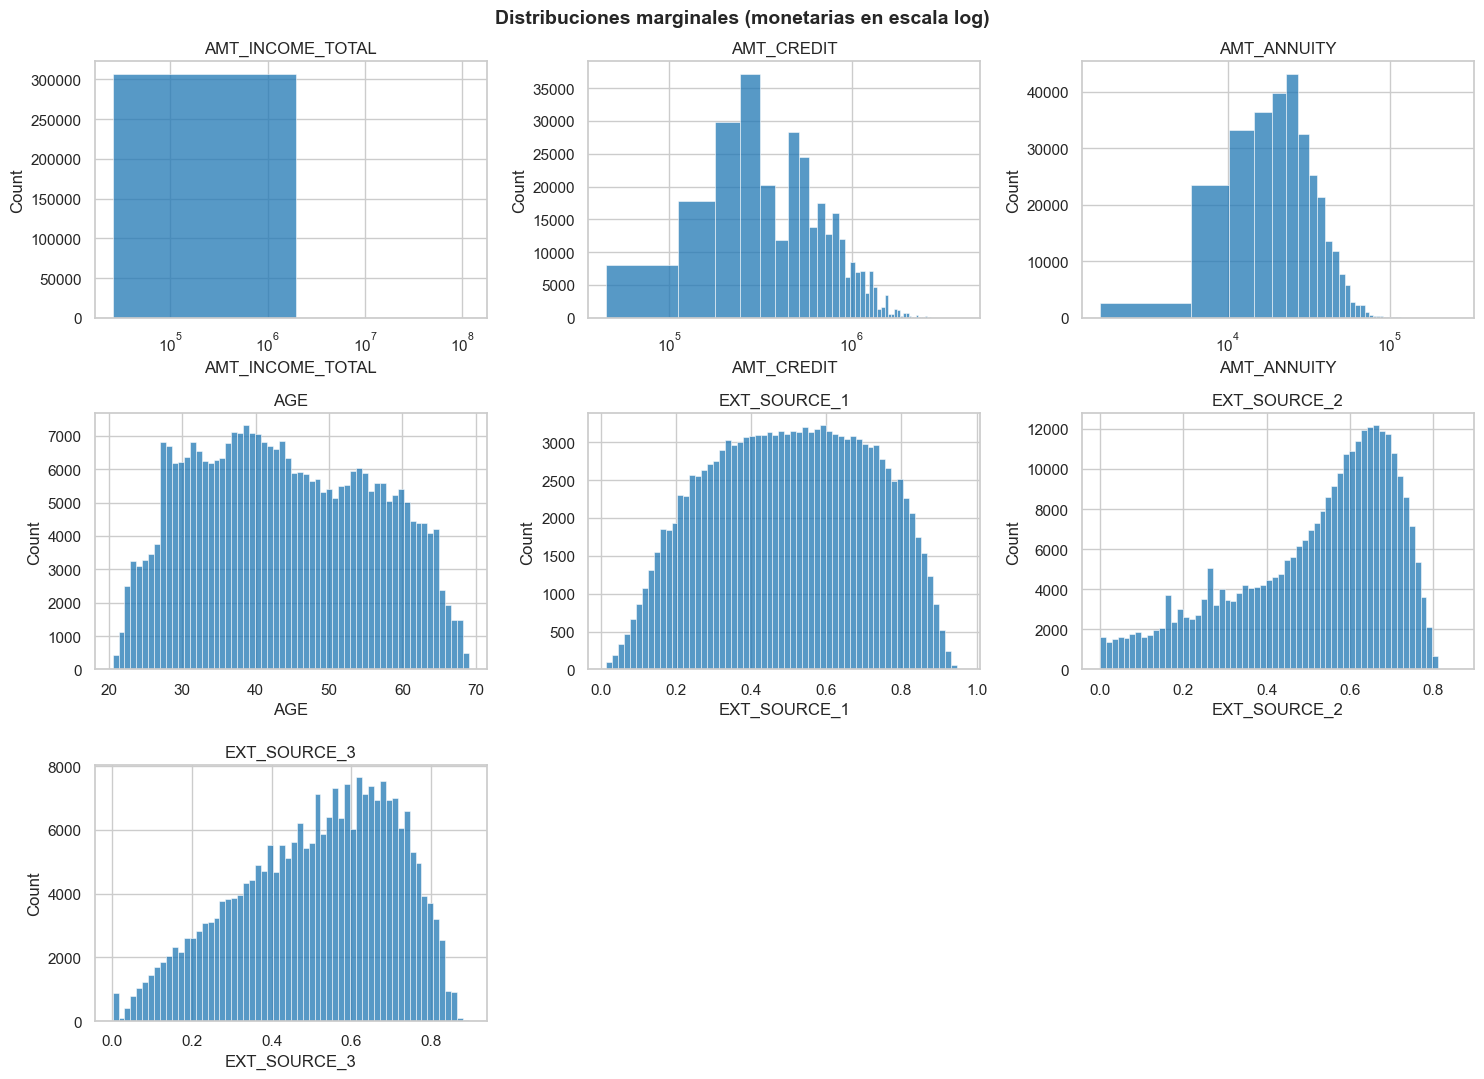

In [6]:
marginal_cols = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AGE",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
]
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), marginal_cols):
    sns.histplot(df[col].dropna(), bins=60, ax=ax, color="tab:blue")
    ax.set_title(col)
    # Escala log en x para las monetarias muy sesgadas
    if col in ("AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"):
        ax.set_xscale("log")
for ax in axes.ravel()[len(marginal_cols):]:
    ax.axis("off")
fig.suptitle("Distribuciones marginales (monetarias en escala log)", fontsize=14, weight="bold")
fig.tight_layout()
plt.show()

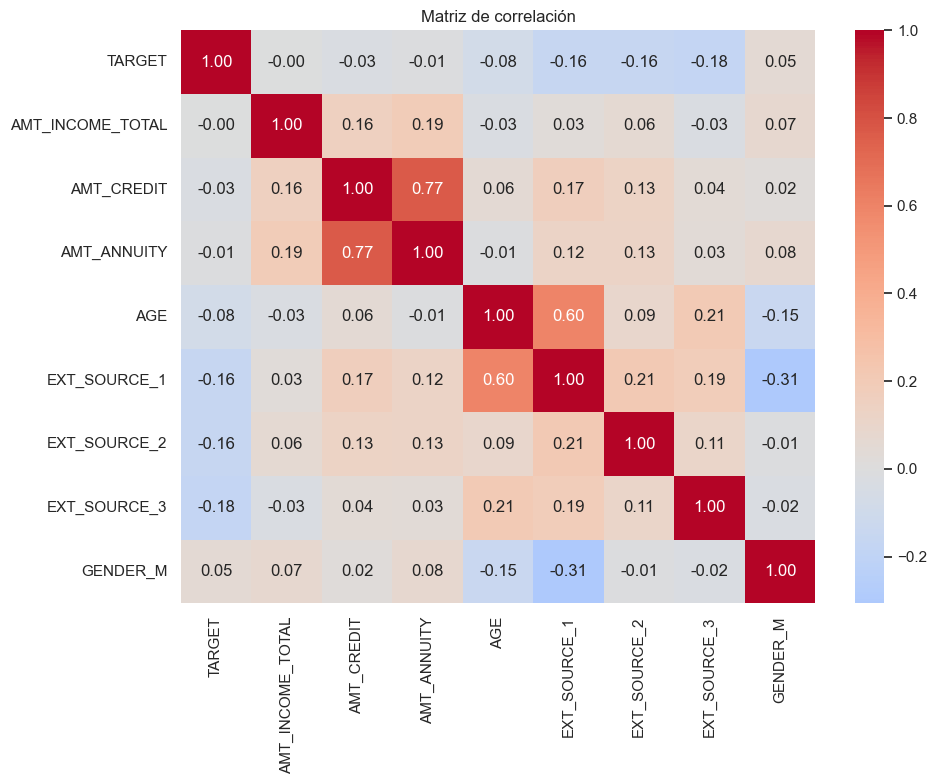

In [7]:
# Matriz de correlación. CODE_GENDER se codifica numéricamente igual que el pipeline (M->1, F->0)
corr_df = df[[
    "TARGET", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AGE",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
]].copy()
corr_df["GENDER_M"] = df["CODE_GENDER"].map({"M": 1, "F": 0, "XNA": 0})

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

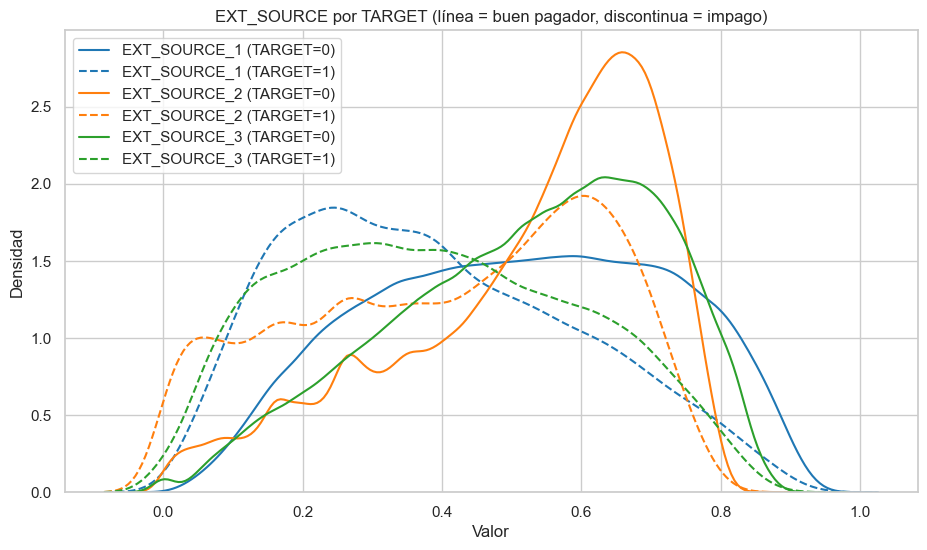

In [8]:
# Capacidad discriminante de los EXT_SOURCE: densidad por clase
plt.figure(figsize=(11, 6))
colores = ["tab:blue", "tab:orange", "tab:green"]
for var, color in zip(EXT_SOURCE_COLS, colores):
    sns.kdeplot(data=df[df["TARGET"] == 0], x=var, color=color, linestyle="-",
                label=f"{var} (TARGET=0)")
    sns.kdeplot(data=df[df["TARGET"] == 1], x=var, color=color, linestyle="--",
                label=f"{var} (TARGET=1)")
plt.title("EXT_SOURCE por TARGET (línea = buen pagador, discontinua = impago)")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.show()

## 3. Desbalanceo de clases (~11:1)

`TARGET` está fuertemente desbalanceado: aproximadamente **11 buenos pagadores por cada impago** (~8% de clase positiva). Con este desbalanceo, la *accuracy* es engañosa (un modelo trivial que predice siempre 0 acierta ~92%). Por eso el objetivo y métrica del Tuner es **AUC**, no accuracy, y el desbalanceo se trata con `class_weight` / BCE ponderada en entrenamiento, **no** dentro del término de equidad.

TARGET
0    282686
1     24825
Name: count, dtype: int64

Proporción clase positiva (impago): 0.0807
Ratio 0:1 = 11.4 : 1


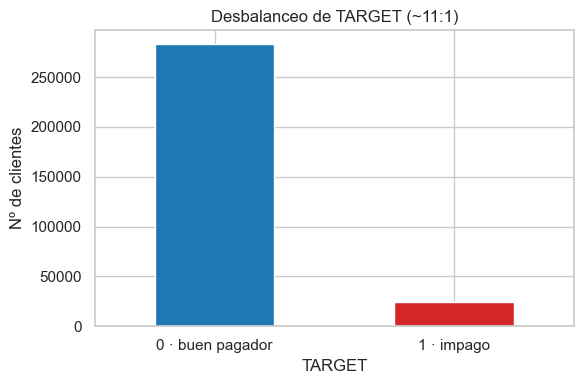

In [9]:
counts = df["TARGET"].value_counts().sort_index()
ratio = counts[0] / counts[1]
print(counts)
print(f"\nProporción clase positiva (impago): {df['TARGET'].mean():.4f}")
print(f"Ratio 0:1 = {ratio:.1f} : 1")

ax = counts.plot(kind="bar", figsize=(6, 4), color=["tab:blue", "tab:red"])
ax.set_xticklabels(["0 · buen pagador", "1 · impago"], rotation=0)
ax.set_title(f"Desbalanceo de TARGET (~{ratio:.0f}:1)")
ax.set_ylabel("Nº de clientes")
plt.tight_layout()
plt.show()

## 4. Canal custom — ratio de endeudamiento y calibración de `k`

La `DebtRatioCustomLayer` calcula `ratio = AMT_CREDIT / AMT_INCOME_TOTAL` y lo satura con `tanh(ratio / k)`. El hiperparámetro `k` se calibra como el **percentil 95 del ratio en train** (disciplina anti-fuga: se usa `X_custom_train` del pipeline, nunca val/test).

**Interpretación de `k`.** Si `k = p95`, entonces un cliente con `ratio = k` se mapea a `tanh(1) ≈ 0.76`. No es un punto de saturación dura: el 95% de los clientes cae por debajo de la zona casi-plana, y la cola del 5% se comprime suavemente sin anular el gradiente (a diferencia de un `clip`).

k = percentil 95 del ratio (train) = 9.1453
tanh(ratio=k / k) = tanh(1) = 0.7616


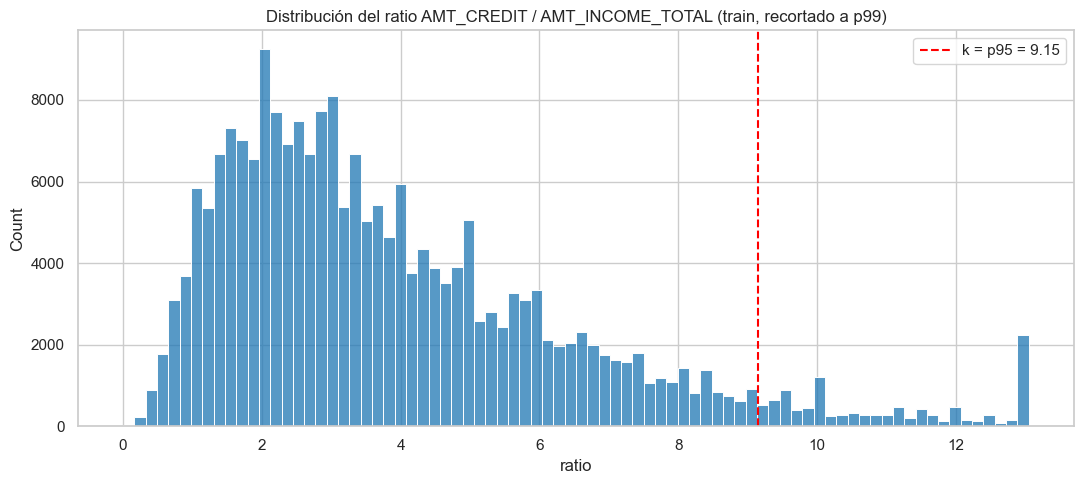

In [10]:
# Ratio SOLO en train, a partir del canal custom del pipeline [credit, income]
ratio_train = X_custom_train[:, 0] / X_custom_train[:, 1]
k = float(np.percentile(ratio_train, 95))
print(f"k = percentil 95 del ratio (train) = {k:.4f}")
print(f"tanh(ratio=k / k) = tanh(1) = {np.tanh(1.0):.4f}")

plt.figure(figsize=(11, 5))
clip_hi = np.percentile(ratio_train, 99)
sns.histplot(np.clip(ratio_train, 0, clip_hi), bins=80, color="tab:blue")
plt.axvline(k, color="red", linestyle="--", label=f"k = p95 = {k:.2f}")
plt.title("Distribución del ratio AMT_CREDIT / AMT_INCOME_TOTAL (train, recortado a p99)")
plt.xlabel("ratio")
plt.legend()
plt.tight_layout()
plt.show()

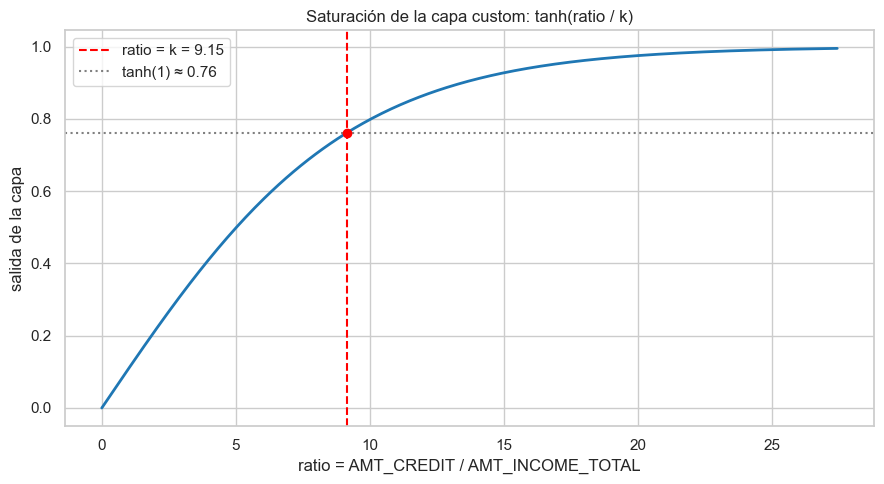

In [11]:
# Curva de saturación tanh(ratio / k): zona de trabajo vs. cola comprimida
x = np.linspace(0, 3 * k, 400)
plt.figure(figsize=(9, 5))
plt.plot(x, np.tanh(x / k), color="tab:blue", lw=2)
plt.axvline(k, color="red", linestyle="--", label=f"ratio = k = {k:.2f}")
plt.axhline(np.tanh(1.0), color="gray", linestyle=":", label="tanh(1) ≈ 0.76")
plt.scatter([k], [np.tanh(1.0)], color="red", zorder=5)
plt.title("Saturación de la capa custom: tanh(ratio / k)")
plt.xlabel("ratio = AMT_CREDIT / AMT_INCOME_TOTAL")
plt.ylabel("salida de la capa")
plt.legend()
plt.tight_layout()
plt.show()

## 5. `AMT_ANNUITY` → `log1p` + `RobustScaler`

`AMT_ANNUITY` es la única monetaria del canal denso. Su distribución original está muy sesgada a la derecha con cola larga; `log1p` la aproxima a una forma más simétrica, y `RobustScaler` (centra en la mediana, escala por IQR) absorbe los outliers restantes sin dejar que dominen el escalado. Es exactamente lo que aplica `data.py` (`log1p` + `RobustScaler`, ambos ajustados solo en train).

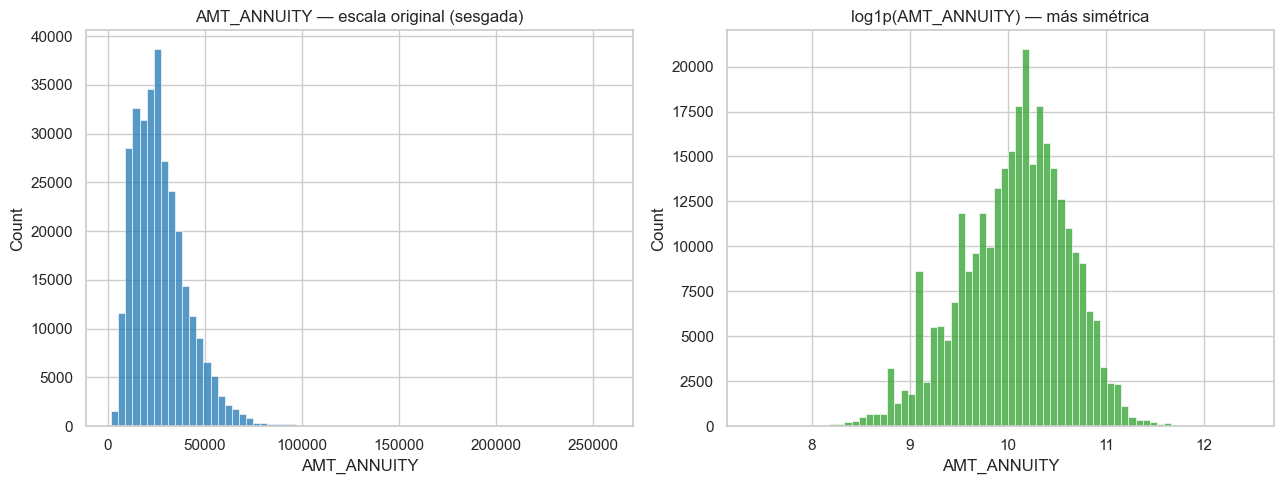

Asimetría (skew) original : 1.580
Asimetría (skew) log1p    : -0.346


In [12]:
annuity = df["AMT_ANNUITY"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(annuity, bins=70, ax=axes[0], color="tab:blue")
axes[0].set_title("AMT_ANNUITY — escala original (sesgada)")
sns.histplot(np.log1p(annuity), bins=70, ax=axes[1], color="tab:green")
axes[1].set_title("log1p(AMT_ANNUITY) — más simétrica")
fig.tight_layout()
plt.show()

print(f"Asimetría (skew) original : {annuity.skew():.3f}")
print(f"Asimetría (skew) log1p    : {np.log1p(annuity).skew():.3f}")

## 6. Missingness en `EXT_SOURCE_1/2/3` → flags de imputación

Los `EXT_SOURCE` son las variables más predictivas, pero también las que más nulos tienen — `EXT_SOURCE_1` ronda el **56%**. El pipeline los imputa con la mediana de train, pero **antes** guarda un flag binario `is_imputed_*` por cada uno. Esto permite al modelo distinguir un score real de uno rellenado, y es especialmente útil para el modelo de incertidumbre (Pilar 4): la ausencia de score externo es señal de un perfil menos fiable. Los flags se calculan fila a fila (`isna()`), no son estadísticos agregados, por lo que no inducen fuga.

> Los flags los genera `src/data.py`; este notebook solo cuantifica y motiva la decisión — no escribe ningún CSV.

% de valores ausentes:
EXT_SOURCE_1   56.4000
EXT_SOURCE_3   19.8000
EXT_SOURCE_2    0.2000


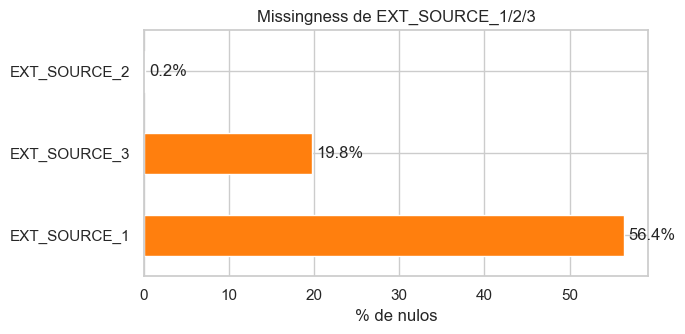

In [13]:
missing_pct = (df[EXT_SOURCE_COLS].isna().mean() * 100).round(1).sort_values(ascending=False)
print("% de valores ausentes:")
print(missing_pct.to_string())

ax = missing_pct.plot(kind="barh", figsize=(7, 3.5), color="tab:orange")
ax.set_xlabel("% de nulos")
ax.set_title("Missingness de EXT_SOURCE_1/2/3")
for i, v in enumerate(missing_pct):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

## 7. Variable sensible `CODE_GENDER`

`CODE_GENDER` es la variable **sensible** del taller. El dataset tiene más mujeres que hombres, y en esta muestra los hombres presentan mayor tasa de impago. Se codifica de forma coherente con el pipeline: **`M → 1`, `F → 0`, `XNA → 0`** (los `XNA` son residuales).

**Decisión base del equipo: `include_gender_in_X=False`.** El género **no** entra como feature; viaja solo como `s` y en `y_ext` (columna 1) para que la FAIR loss penalice la dependencia `λ · ρ(ŷ, s)²`. Así garantizamos que el modelo base **no usa directamente el género** como input. Esto diverge conscientemente de la recomendación del curso (incluir la sensible y forzar independencia); la variante queda disponible con `include_gender_in_X=True`. Ver el disclaimer de `REPO_DESIGN.md`.

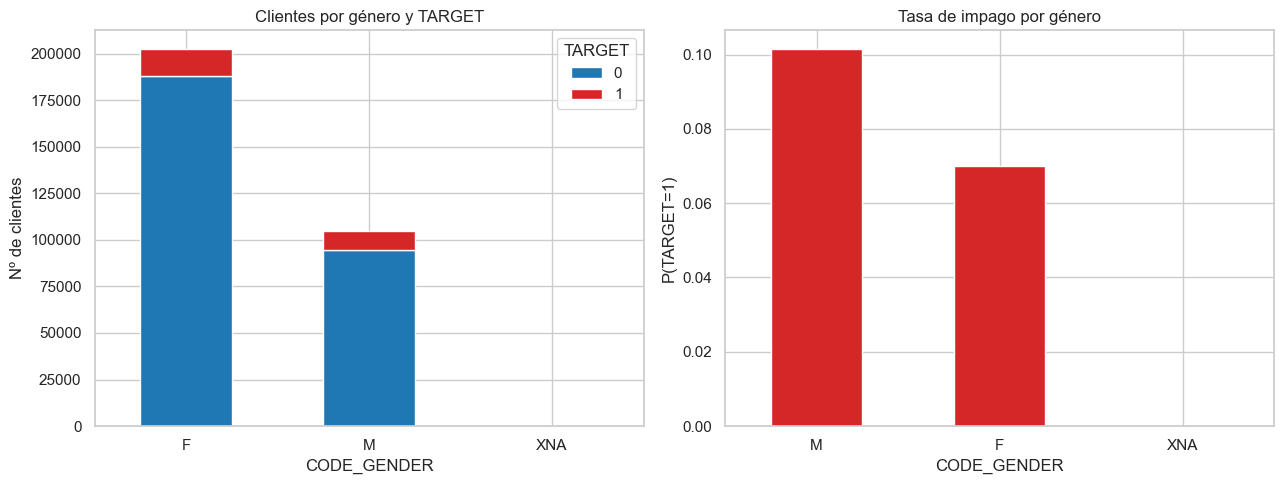

Tasa de impago por género:
CODE_GENDER
M     0.1014
F     0.0700
XNA   0.0000

Proporción de hombres (s=1) en train: 0.3421


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Composición por género y TARGET
(df.groupby(["CODE_GENDER", "TARGET"]).size().unstack()
   .plot(kind="bar", stacked=True, ax=axes[0], color=["tab:blue", "tab:red"]))
axes[0].set_title("Clientes por género y TARGET")
axes[0].set_xlabel("CODE_GENDER")
axes[0].set_ylabel("Nº de clientes")
axes[0].tick_params(axis="x", rotation=0)

# Tasa de impago por género
default_rate = df.groupby("CODE_GENDER")["TARGET"].mean().sort_values(ascending=False)
default_rate.plot(kind="bar", ax=axes[1], color="tab:red")
axes[1].set_title("Tasa de impago por género")
axes[1].set_xlabel("CODE_GENDER")
axes[1].set_ylabel("P(TARGET=1)")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()

print("Tasa de impago por género:")
print(default_rate.to_string())
print(f"\nProporción de hombres (s=1) en train: {s_train.mean():.4f}")

## 8. Conclusiones — decisiones de preprocesado cerradas

| Decisión | Justificación (en este EDA) |
|---|---|
| **AUC** como objetivo del Tuner (no accuracy) | Desbalanceo ~11:1; la accuracy es engañosa (§3). |
| `k = p95(ratio)` en train para la capa custom | `ratio = k → tanh(1) ≈ 0.76`; saturación suave de la cola (§4). |
| `AMT_CREDIT` y `AMT_INCOME_TOTAL` **crudas** al canal custom | Preservan el significado económico del ratio (§4). |
| `log1p` + `RobustScaler` para `AMT_ANNUITY` | Distribución sesgada con outliers (§5). |
| Flags `is_imputed_*` para `EXT_SOURCE_1/2/3` | Hasta ~56% de nulos; señal de fiabilidad del perfil (§6). |
| `CODE_GENDER` **fuera** de `X` por defecto | Garantía dura: el modelo base no usa el género como input (§7). |

Estas decisiones ya están implementadas en `src/data.py` y son el contrato que consumen `02_model.ipynb` y `03_uncertainty.ipynb`.